<a href="https://colab.research.google.com/github/DeemAdel/lab6_imageProcessing/blob/main/ImageProcessing_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, fftshift, ifftshift

%matplotlib inline

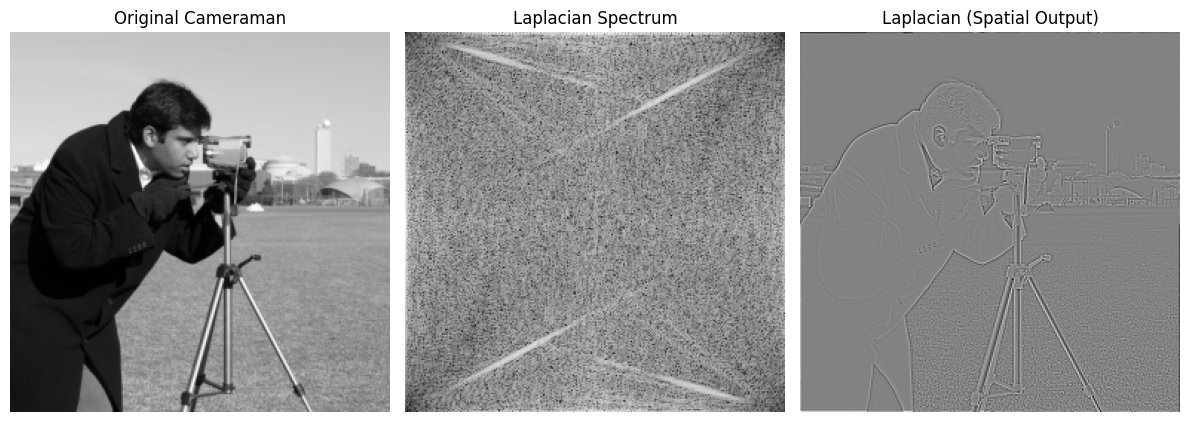

In [2]:
# --- Code from the lab manual ---
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256))   # Resize for faster FFT (optional)

# Get image size
M, N = image.shape

# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)   # column vector of frequencies for rows
v = np.fft.fftfreq(N).reshape(1, -1)   # row vector of frequencies for columns

# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

# Apply 2D FFT
F = np.fft.fft2(image)

# Apply Laplacian filter in frequency domain (pointwise multiplication)
F_lap = F * laplacian_filter

# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman'); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum'); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)'); plt.axis('off')

plt.tight_layout(); plt.show()

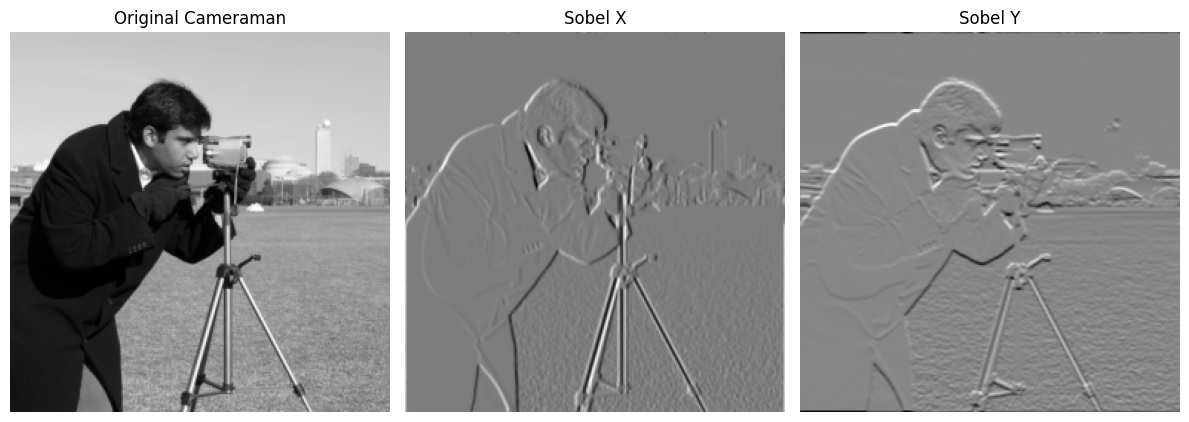

In [3]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    M, N = shape
    start_row = M // 2 - kh // 2
    start_col = N // 2 - kw // 2
    padded[start_row:start_row + kh, start_col:start_col + kw] = kernel
    padded = ifftshift(padded)
    return fft2(padded)

H_x = center_embed_kernel(sobel_x, image.shape)
H_y = center_embed_kernel(sobel_y, image.shape)

F_sobel_x = F * H_x
F_sobel_y = F * H_y


sobel_x_image = ifft2(F_sobel_x).real
sobel_y_image = ifft2(F_sobel_y).real


plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman'); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sobel_x_image, cmap='gray')
plt.title('Sobel X'); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sobel_y_image, cmap='gray')
plt.title('Sobel Y'); plt.axis('off')

plt.tight_layout(); plt.show()